# 03 — Feature Engineering

**What this notebook does:** Derives the 15 clustering features and xG model features from raw Understat shot data. Shows before/after transformation, feature distributions, correlation matrix, and confirms zero nulls in the clustering feature set.

**Key output:** `data/processed/shots_features.csv` — 490k shots × 32 feature columns.


In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd
import numpy as np
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
from pathlib import Path
OUTPUTS_DIR = Path('../data/outputs')
PROCESSED_DIR = Path('../data/processed')
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
from src.scraper import load_understat_cache
from src.features import engineer_understat, add_game_state, CLUSTER_FEATURES


## 3.1  Load raw data (5 sample rows)

In [2]:
raw = load_understat_cache()
print(f"Raw shape: {raw.shape}")
print(f"Columns: {raw.columns.tolist()}")
raw[['player', 'result', 'X', 'Y', 'xG', 'situation', 'shotType', 'lastAction']].head()


Raw shape: (490204, 21)
Columns: ['id', 'minute', 'result', 'X', 'Y', 'xG', 'player', 'h_a', 'player_id', 'situation', 'season', 'shotType', 'match_id', 'h_team', 'a_team', 'h_goals', 'a_goals', 'date', 'player_assisted', 'lastAction', 'league']


,player,result,X,Y,xG,situation,shotType,lastAction
0,Thomas Müller,SavedShot,0.903,0.239,0.034118,OpenPlay,RightFoot,Chipped
1,Arjen Robben,SavedShot,0.852,0.277,0.030941,OpenPlay,LeftFoot,Pass
2,Arjen Robben,BlockedShot,0.803,0.277,0.021718,OpenPlay,LeftFoot,Chipped
3,Thomas Müller,SavedShot,0.871,0.324,0.050345,OpenPlay,LeftFoot,NaN
4,Robert Lewandowski,SavedShot,0.918,0.531,0.111078,OpenPlay,RightFoot,Chipped


## 3.2  Apply feature engineering

In [3]:
print("Engineering features...")
feat = engineer_understat(raw)
print("Adding game state...")
feat = add_game_state(feat)
print(f"\nEngineered shape: {feat.shape}")
print(f"Columns: {feat.columns.tolist()}")
feat[['player_name', 'distance', 'angle', 'is_header', 'preceded_by_cross',
      'preceded_by_layoff', 'shot_in_box', 'game_state', 'goal']].head()


Engineering features...


Adding game state...



Engineered shape: (490204, 32)
Columns: ['shot_id', 'player_id', 'player_name', 'league', 'season', 'match_id', 'minute', 'h_a', 'distance', 'angle', 'shot_in_box', 'is_header', 'is_left_foot', 'is_right_foot', 'from_corner', 'from_set_piece', 'from_freekick', 'open_play', 'preceded_by_cross', 'preceded_by_aerial', 'preceded_by_dribble', 'preceded_by_throughball', 'preceded_by_rebound', 'preceded_by_layoff', 'first_touch', 'one_on_one', 'xg_understat', 'xg_statsbomb', 'goal', 'result', 'source', 'game_state']


,player_name,distance,angle,is_header,preceded_by_cross,preceded_by_layoff,shot_in_box,game_state,goal
0,Christian Eriksen,14.732280,27.035691,0,0,0,1,drawing,0
1,Harry Kane,28.044606,9.028642,0,0,0,1,drawing,0
2,Toby Alderweireld,13.403359,40.908031,1,1,0,1,drawing,0
3,Harry Kane,18.179661,28.950992,0,0,0,1,drawing,0
4,Kyle Walker,16.032780,15.418997,0,0,0,1,drawing,0


## 3.3  Confirm zero nulls in all 15 cluster features

In [4]:
null_check = feat[CLUSTER_FEATURES].isnull().sum()
print("Null counts in cluster features:")
print(null_check.to_string())
assert null_check.sum() == 0, "Found nulls in clustering features!"
print("\n✓ Zero nulls confirmed.")
print(f"\nCluster features ({len(CLUSTER_FEATURES)}):")
for f in CLUSTER_FEATURES:
    print(f"  {f}")


Null counts in cluster features:
distance                   0
angle                      0
is_header                  0
is_right_foot              0
is_left_foot               0
from_corner                0
from_set_piece             0
from_freekick              0
preceded_by_cross          0
preceded_by_aerial         0
preceded_by_dribble        0
preceded_by_throughball    0
preceded_by_rebound        0
preceded_by_layoff         0
shot_in_box                0

✓ Zero nulls confirmed.

Cluster features (15):
  distance
  angle
  is_header
  is_right_foot
  is_left_foot
  from_corner
  from_set_piece
  from_freekick
  preceded_by_cross
  preceded_by_aerial
  preceded_by_dribble
  preceded_by_throughball
  preceded_by_rebound
  preceded_by_layoff
  shot_in_box


## 3.4  Feature distributions

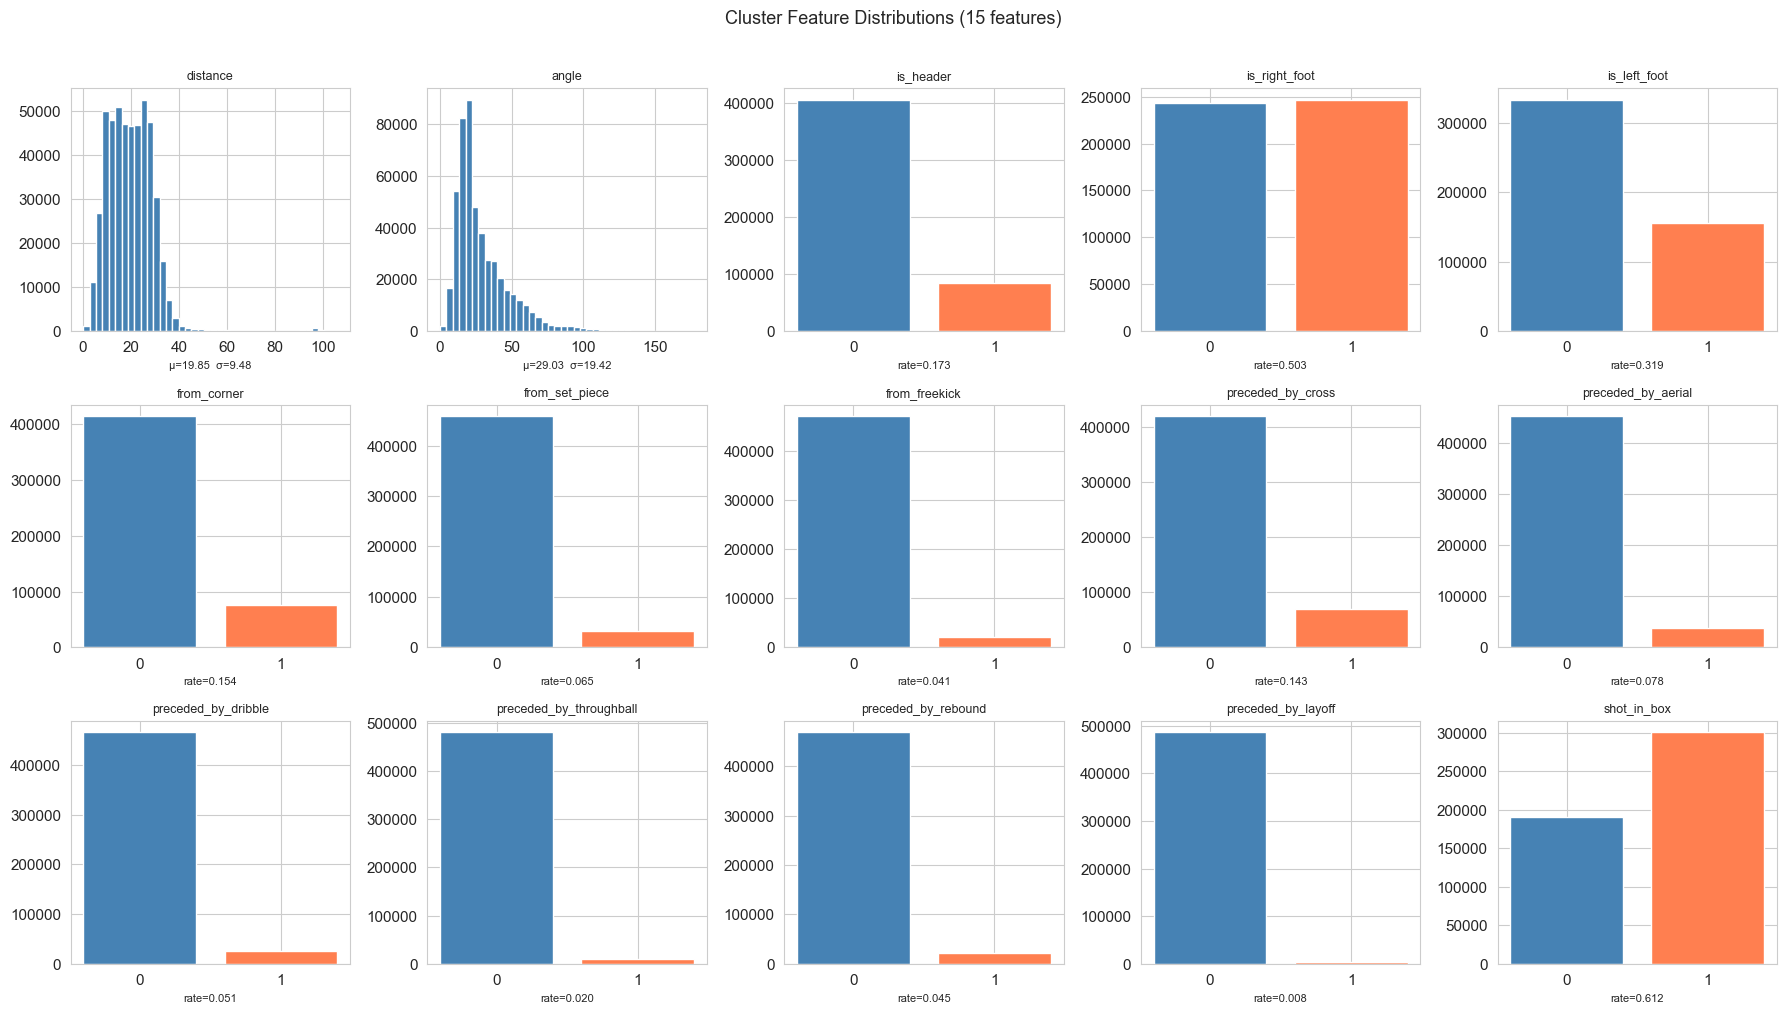

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(CLUSTER_FEATURES):
    ax = axes[i]
    vals = feat[col]
    if vals.nunique() <= 2:
        ax.bar(['0', '1'], [( vals == 0).sum(), (vals == 1).sum()],
               color=['steelblue', 'coral'], edgecolor='white')
        ax.set_title(col, fontsize=9)
        rate = vals.mean()
        ax.set_xlabel(f'rate={rate:.3f}', fontsize=8)
    else:
        ax.hist(vals, bins=40, edgecolor='white', color='steelblue')
        ax.set_title(col, fontsize=9)
        ax.set_xlabel(f'μ={vals.mean():.2f}  σ={vals.std():.2f}', fontsize=8)
    ax.set_ylabel('')

plt.suptitle('Cluster Feature Distributions (15 features)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.5  Correlation matrix of cluster features

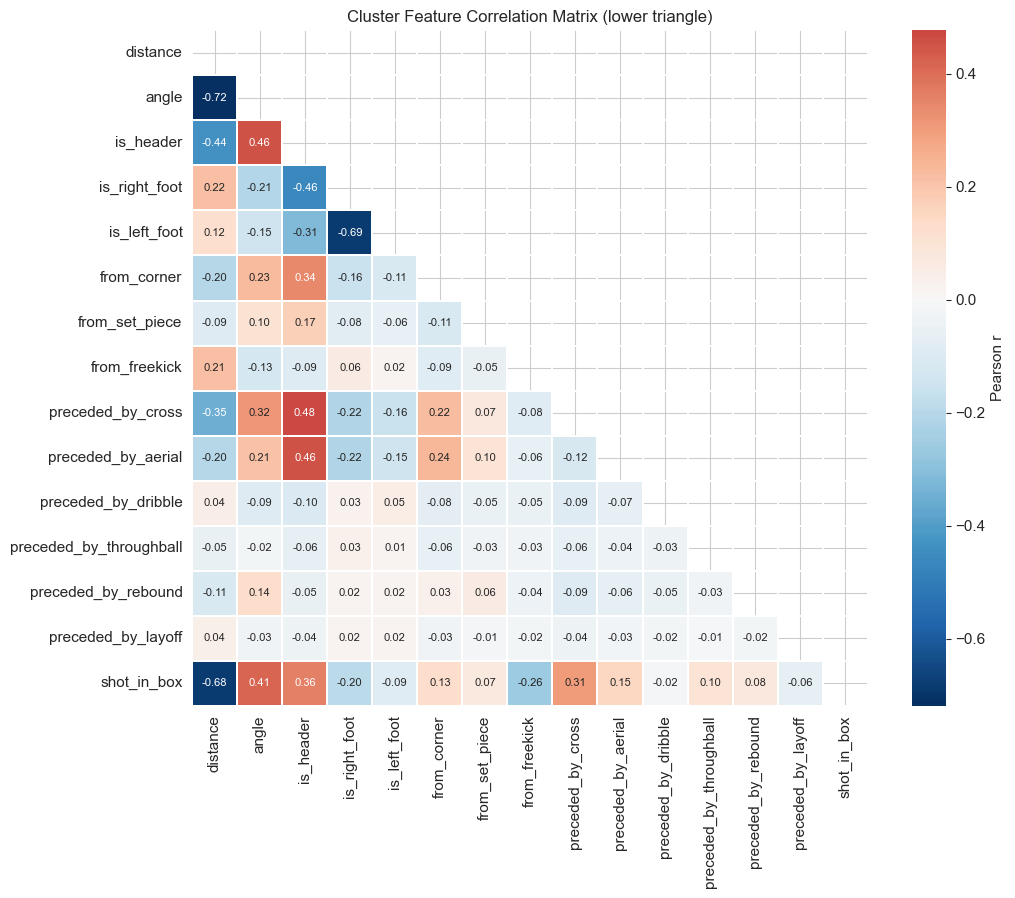

In [6]:
corr = feat[CLUSTER_FEATURES].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.3, ax=ax, mask=mask,
            cbar_kws={'label': 'Pearson r'}, annot_kws={'size': 8})
ax.set_title('Cluster Feature Correlation Matrix (lower triangle)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.6  Save `shots_features.csv`

In [7]:
out_path = PROCESSED_DIR / 'shots_features.csv'
feat.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Shape: {feat.shape}  ({feat.memory_usage(deep=True).sum() / 1e6:.1f} MB)")
feat.describe().round(3)


Saved: ..\data\processed\shots_features.csv


Shape: (490204, 32)  (315.2 MB)


,season,match_id,minute,distance,angle,shot_in_box,is_header,is_left_foot,is_right_foot,from_corner,...,preceded_by_aerial,preceded_by_dribble,preceded_by_throughball,preceded_by_rebound,preceded_by_layoff,first_touch,one_on_one,xg_understat,xg_statsbomb,goal
count,490204.000,490204.000,490204.000,490204.000,490204.000,490204.000,490204.000,490204.000,490204.000,490204.000,...,490204.000,490204.000,490204.000,490204.000,490204.000,490204.0,490204.0,490204.000,0.0,490204.000
mean,2018.987,12877.406,48.702,19.847,29.030,0.612,0.173,0.319,0.503,0.154,...,0.078,0.051,0.020,0.045,0.008,0.0,0.0,0.104,NaN,0.098
std,3.161,7966.968,26.669,9.477,19.419,0.487,0.379,0.466,0.500,0.361,...,0.268,0.220,0.142,0.207,0.089,0.0,0.0,0.148,NaN,0.298
min,2014.000,81.000,0.000,0.316,0.071,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.000,NaN,0.000
25%,2016.000,5725.000,26.000,12.739,16.167,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.025,NaN,0.000
50%,2019.000,12474.000,49.000,19.280,22.295,1.000,0.000,0.000,1.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.051,NaN,0.000
75%,2022.000,18639.250,71.000,26.092,36.963,1.000,0.000,1.000,1.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.094,NaN,0.000
max,2024.000,28353.000,106.000,106.042,177.648,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,0.0,0.0,0.980,NaN,1.000
